# Hälsostudie

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["axes.grid"] = True
plt.rcParams["figure.dpi"] = 120
np.set_printoptions(precision=3)
pd.set_option("display.precision", 3)

In [2]:
data = pd.read_csv("health_study_dataset.csv")
display(data.head())
display(data.info())
display(data.describe())

dup_mask = data.duplicated(keep=False)

print("Antal dubletter", dup_mask.sum())
data[dup_mask].head()

,id,age,sex,height,weight,systolic_bp,cholesterol,smoker,disease
0,1,57,F,168.9,65.8,141.8,4.58,No,0
1,2,47,M,180.4,95.9,144.8,5.18,Yes,0
2,3,59,F,169.9,82.2,151.7,6.16,No,0
3,4,72,M,157.7,93.1,151.0,6.63,No,0
4,5,46,M,192.6,104.1,144.1,5.21,No,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           800 non-null    int64  
 1   age          800 non-null    int64  
 2   sex          800 non-null    object 
 3   height       800 non-null    float64
 4   weight       800 non-null    float64
 5   systolic_bp  800 non-null    float64
 6   cholesterol  800 non-null    float64
 7   smoker       800 non-null    object 
 8   disease      800 non-null    int64  
dtypes: float64(4), int64(3), object(2)
memory usage: 56.4+ KB


None

,id,age,height,weight,systolic_bp,cholesterol,disease
count,800.000,800.000,800.000,800.000,800.000,800.000,800.000
mean,400.500,49.426,171.849,73.413,149.179,4.929,0.059
std,231.084,14.501,9.804,13.685,12.793,0.848,0.235
min,1.000,18.000,144.400,33.700,106.800,2.500,0.000
25%,200.750,39.000,164.775,64.800,140.900,4.328,0.000
50%,400.500,50.000,171.350,73.200,149.400,4.970,0.000
75%,600.250,59.000,178.925,82.600,157.600,5.482,0.000
max,800.000,90.000,200.400,114.400,185.900,7.880,1.000


Antal dubletter 0


,id,age,sex,height,weight,systolic_bp,cholesterol,smoker,disease


In [3]:
clean = data.dropna().copy()

clean.columns = (clean.columns
            .str.strip()
            .str.replace(" ", "_")
            .str.lower())

In [4]:
columns = ["age", "weight", "height", "systolic_bp", "cholesterol"]

summary_stats = (
    clean[columns]
    .agg(["mean", "median", "min", "max"])
    .round(2)
)

summary_stats

,age,weight,height,systolic_bp,cholesterol
mean,49.43,73.41,171.85,149.18,4.93
median,50.00,73.20,171.35,149.40,4.97
min,18.00,33.70,144.40,106.80,2.50
max,90.00,114.40,200.40,185.90,7.88


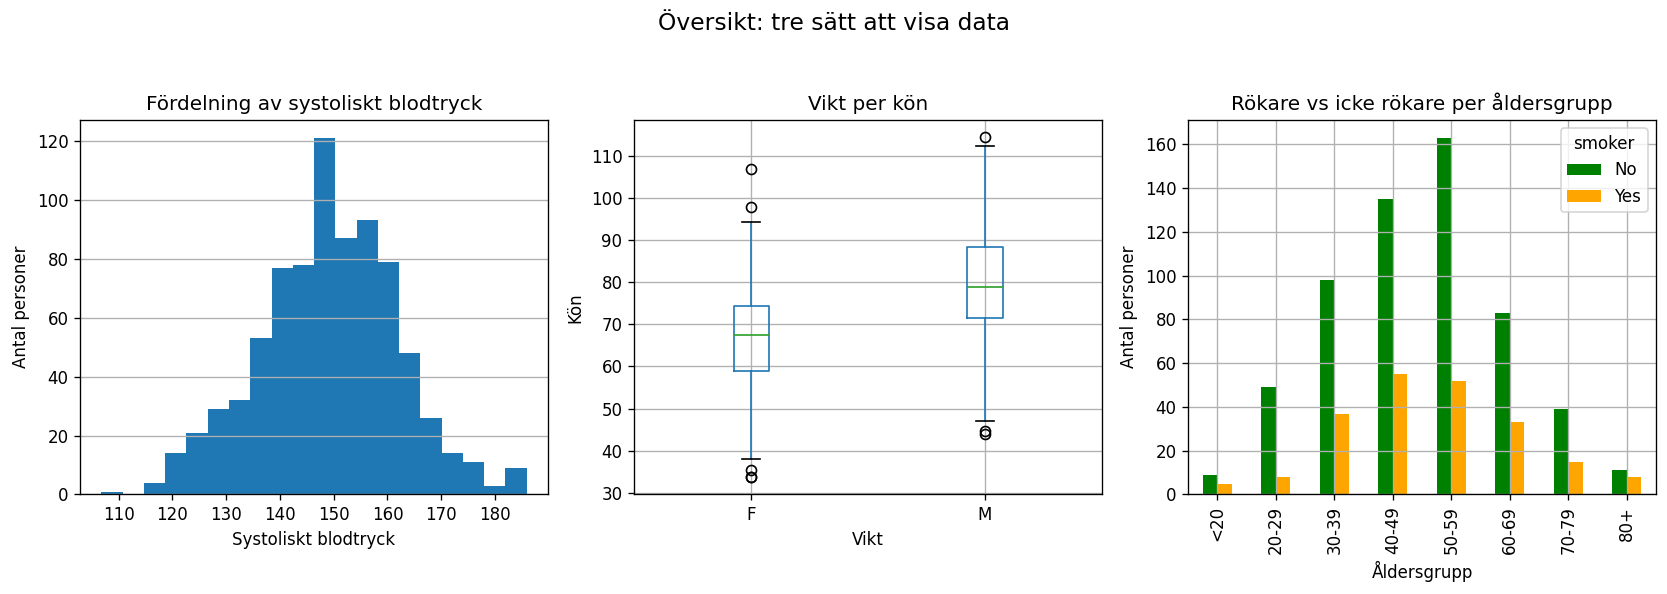

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharex=False, sharey=False) 

axes[0].hist(clean.systolic_bp.dropna(), bins=20)
axes[0].set_title("Fördelning av systoliskt blodtryck")
axes[0].set_xlabel("Systoliskt blodtryck")
axes[0].set_ylabel("Antal personer")
axes[0].grid(True, axis="y")
axes[0].xaxis.grid(False)  

clean.boxplot(column="weight", by="sex", ax=axes[1])
axes[1].set_title("Vikt per kön")
axes[1].set_xlabel("Vikt")
axes[1].set_ylabel("Kön")
axes[1].grid(True, axis="y")

bins = [0, 20, 30, 40, 50, 60, 70, 80, 100]
labels = ["<20", "20-29", "30-39", "40-49", "50-59", "60-69", "70-79", "80+"]
age_bins = pd.cut(clean["age"], bins=bins, labels=labels, right=False)
cross = pd.crosstab(age_bins, clean["smoker"])

cross.plot(kind="bar", ax=axes[2], color=["green", "orange"])
axes[2].set_title("Rökare vs icke rökare per åldersgrupp")
axes[2].set_xlabel("Åldersgrupp")
axes[2].set_ylabel("Antal personer")
axes[2].grid(True, axis="y")

fig.suptitle("Översikt: tre sätt att visa data", fontsize=14)
plt.tight_layout()
plt.subplots_adjust(top=0.8)
plt.show()


In [ ]:
andel_sjuka = (clean["disease"].sum() / len(clean))

np.random.seed(123)
n = 1000

simulerat_sjuka = np.random.choice([0, 1], size=n, p=[1-andel_sjuka, andel_sjuka])
andel_sjuka_simulerat = simulerat_sjuka.sum() / n

print(f"Andel observerat sjuka: {andel_sjuka*100:.1f}%")
print(f"Andel simulerat sjuka: {andel_sjuka_simulerat*100:.1f}%")

Andel observerat sjuka: 5.9%
Andel simulerat sjuka: 6.6%
